# SVI loss curves across refits

For each **experiment** (configuration folder), this notebook loads `losses.txt` from a **random subset** of `run_*` directories and plots **loss vs epoch** (one trace per refit).

**Configuration list:** Same pattern as `r2_comparison.ipynb` — set **`EXPERIMENT_SOURCES`** below (`root` + `experiments` subdirs).

**Parameters:** `N_RUNS_TO_PLOT` (max traces per experiment), `RNG_SEED` (reproducible subsample). Use `YSCALE = "log"` if magnitudes differ a lot.

Loss is the Pyro **Trace_ELBO** objective from `parmigiano_joint.fit_parmigiano` (one value per epoch; lower is better when the estimator is consistent).

In [ ]:
from __future__ import annotations

import os
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

_plot_pkg = Path.cwd().resolve()
if _plot_pkg.name != "plotting" and (_plot_pkg / "plotting").is_dir():
    _plot_pkg = _plot_pkg / "plotting"
if str(_plot_pkg) not in sys.path:
    sys.path.insert(0, str(_plot_pkg))

from experiment_sources import get_experiment_sources


def _src_anchor_for_paths() -> Path:
    """Directory that holds experiment roots (parent of plotting/ when cwd is src or plotting)."""
    p = Path.cwd().resolve()
    if p.name == "plotting" and p.parent.is_dir():
        return p.parent
    if (p / "plotting").is_dir():
        return p
    return p


def _resolve_experiment_root(raw: str) -> str:
    """Absolute path for EXPERIMENT_SOURCES root; avoids cwd doubling (see docstring in repo)."""
    s = os.path.expanduser(raw.strip())
    if os.path.isabs(s):
        return os.path.normpath(s)
    norm = s.replace("\\", "/").strip("/")
    for prefix in (
        "firvTWAS/parmigiano-expr/src/",
        "parmigiano-expr/src/",
    ):
        if norm.startswith(prefix):
            norm = norm[len(prefix) :]
            break
    anchor = _src_anchor_for_paths()
    return str((anchor / norm).resolve())


# ---------------------------------------------------------------------------
# dist>0 ChromBPNet clip10 grid — built via experiment_sources.dist_gt0_chrombpnet_clip10_sources.
# For custom lr tags: get_experiment_sources with only chrombpnet grids, or call
# dist_gt0_chrombpnet_clip10_sources(lr_tags=["001","01","05"]) and assign to EXPERIMENT_SOURCES.
# ---------------------------------------------------------------------------
EXPERIMENT_SOURCES = get_experiment_sources("dist_gt0_chrombpnet_grid")

RUN_DIR_RE = re.compile(r"^run_(\d+)$", re.I)


def _normalize_experiment_source(entry: dict | tuple | list) -> tuple[str, list[str], str]:
    if isinstance(entry, dict):
        root = _resolve_experiment_root(str(entry["root"]))
        exps = entry["experiments"]
        prefix = entry.get("label_prefix")
    elif isinstance(entry, (tuple, list)) and len(entry) >= 2:
        root = _resolve_experiment_root(str(entry[0]))
        exps = entry[1]
        prefix = entry[2] if len(entry) > 2 else None
    else:
        raise TypeError(
            "Each EXPERIMENT_SOURCES item must be a dict with keys root, experiments "
            "or a tuple (root, experiments[, label_prefix])."
        )
    if not isinstance(exps, (list, tuple)):
        raise TypeError(f"experiments must be a list for root {root!r}")
    prefix = prefix or os.path.basename(os.path.normpath(root))
    return root, [str(e) for e in exps], prefix


def discover_configurations(sources: list | None = None) -> list[tuple[str, str]]:
    """[(configuration_label, path_to_experiment_dir), ...]."""
    if sources is None:
        sources = EXPERIMENT_SOURCES
    configs: list[tuple[str, str]] = []
    seen: set[str] = set()

    for entry in sources:
        root, exps, label_prefix = _normalize_experiment_source(entry)
        if not os.path.isdir(root):
            print(f"Warning: root does not exist (skipped): {root}")
            continue
        for exp in exps:
            p = os.path.join(root, exp)
            if not os.path.isdir(p):
                print(f"Warning: experiment folder missing (skipped): {p}")
                continue
            ap = os.path.abspath(p)
            if ap in seen:
                continue
            seen.add(ap)
            label = f"{label_prefix}/{exp}"
            configs.append((label, ap))
    return configs


def run_index(name: str) -> int | None:
    m = RUN_DIR_RE.match(name)
    return int(m.group(1)) if m else None


def list_runs(config_path: str) -> list[tuple[int, str]]:
    out: list[tuple[int, str]] = []
    for name in os.listdir(config_path):
        ri = run_index(name)
        if ri is None:
            continue
        p = os.path.join(config_path, name)
        if os.path.isdir(p):
            out.append((ri, p))
    out.sort(key=lambda t: t[0])
    return out


def load_losses(run_path: str) -> np.ndarray | None:
    """1D array of loss per epoch from losses.txt."""
    fp = os.path.join(run_path, "losses.txt")
    if not os.path.isfile(fp):
        return None
    try:
        v = np.loadtxt(fp, dtype=float)
        if v.ndim == 0:
            v = np.array([float(v)])
        v = np.asarray(v, dtype=float).ravel()
        if len(v) == 0:
            return None
        return v
    except Exception:
        return None


def plot_loss_curves(
    n_runs_per_experiment: int = 3,
    rng_seed: int = 0,
    yscale: str = "linear",
    sources: list | None = None,
):
    """
    One figure per configuration; each figure overlays a random subset of runs.
    """
    configs = discover_configurations(sources)
    rng = np.random.default_rng(rng_seed)

    for cfg_label, cfg_path in configs:
        runs = list_runs(cfg_path)
        valid = [(ri, rp) for ri, rp in runs if load_losses(rp) is not None]
        if not valid:
            print(f"Skip (no losses.txt): {cfg_label}")
            continue

        k = min(int(n_runs_per_experiment), len(valid))
        pick = rng.choice(len(valid), size=k, replace=False)
        picked = [valid[i] for i in sorted(pick)]

        fig, ax = plt.subplots(figsize=(9, 4.2), constrained_layout=True)
        for j, (ri, rp) in enumerate(picked):
            loss = load_losses(rp)
            assert loss is not None
            x = np.arange(len(loss), dtype=float)
            ax.plot(
                x,
                loss,
                label=f"run_{ri}",
                color=f"C{j % 10}",
                lw=1.4,
                alpha=0.9,
            )
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.set_title(cfg_label)
        ax.set_yscale(yscale)
        ax.legend(title="Refit", fontsize=9, loc="best")
        ax.grid(True, alpha=0.35)
        plt.show()
        plt.close(fig)

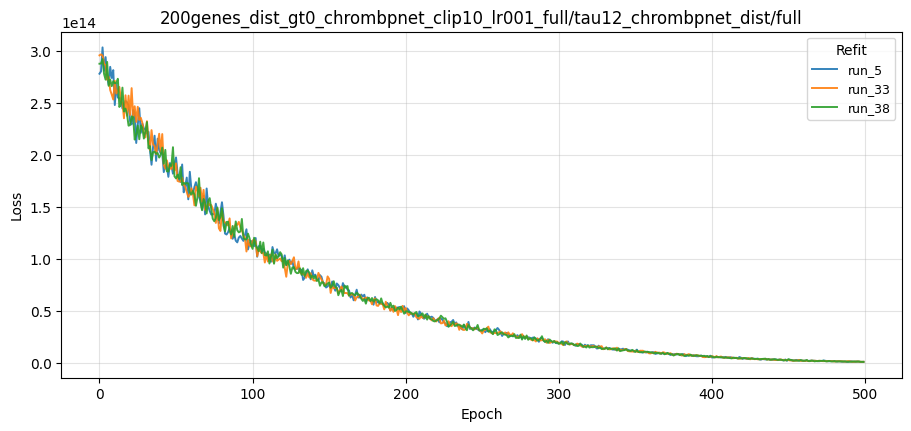

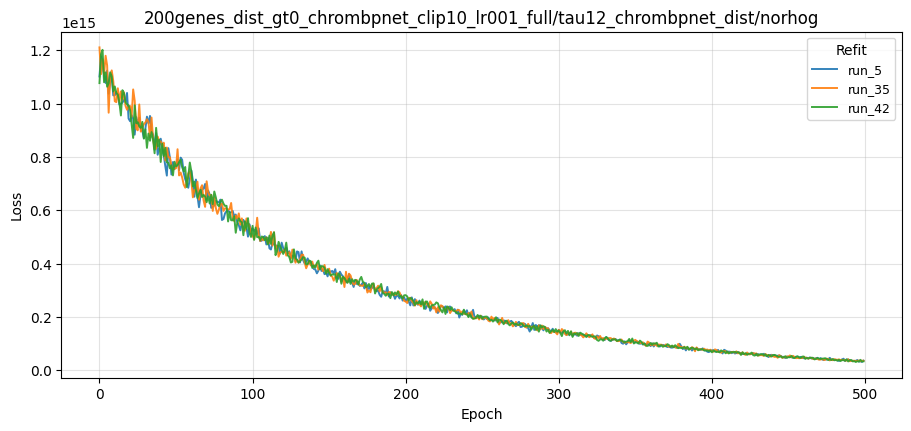

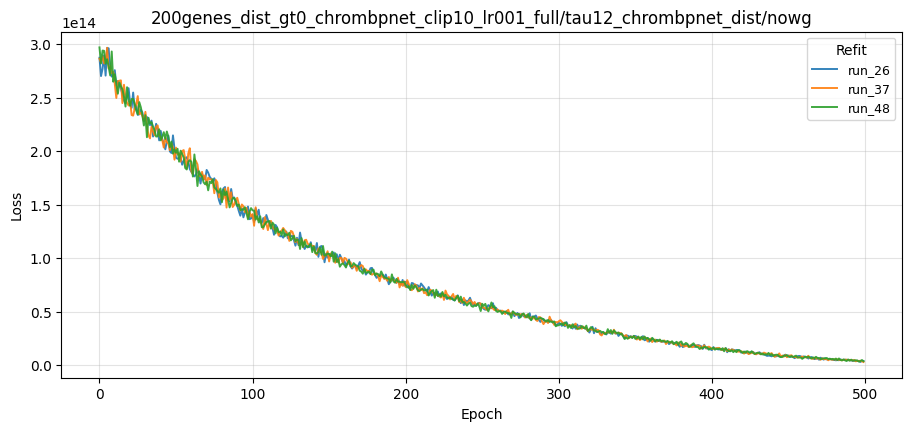

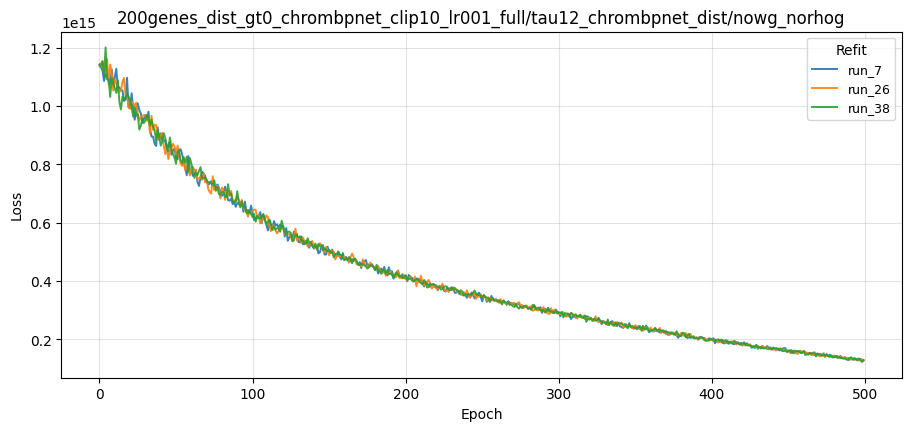

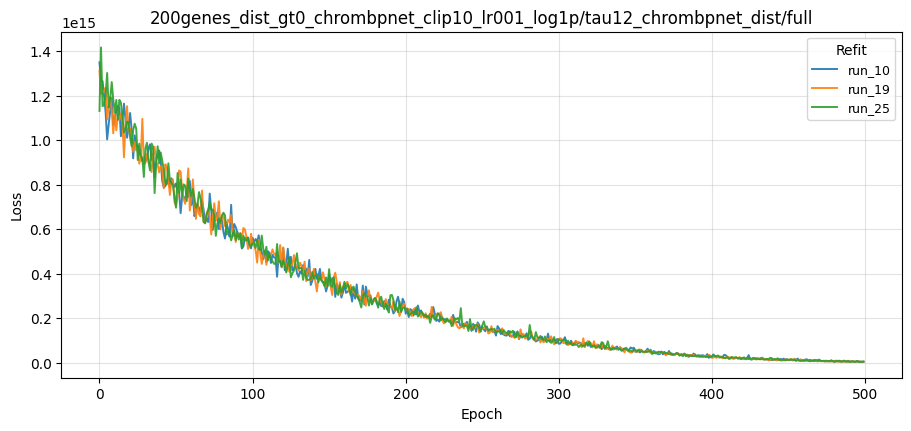

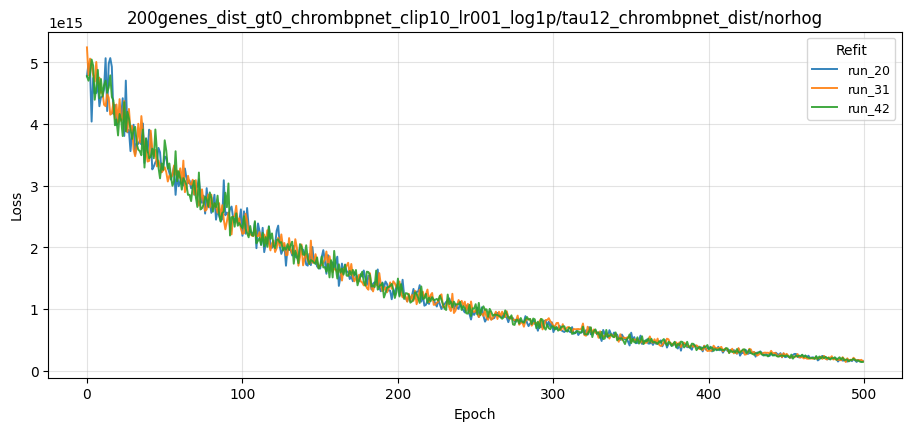

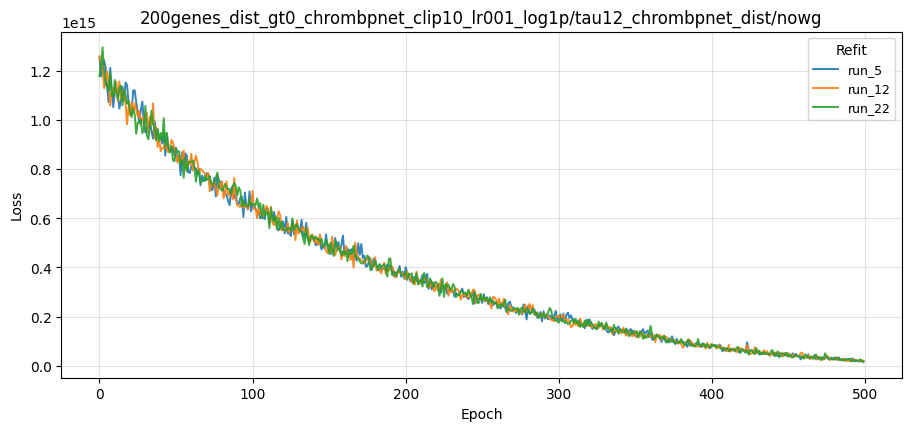

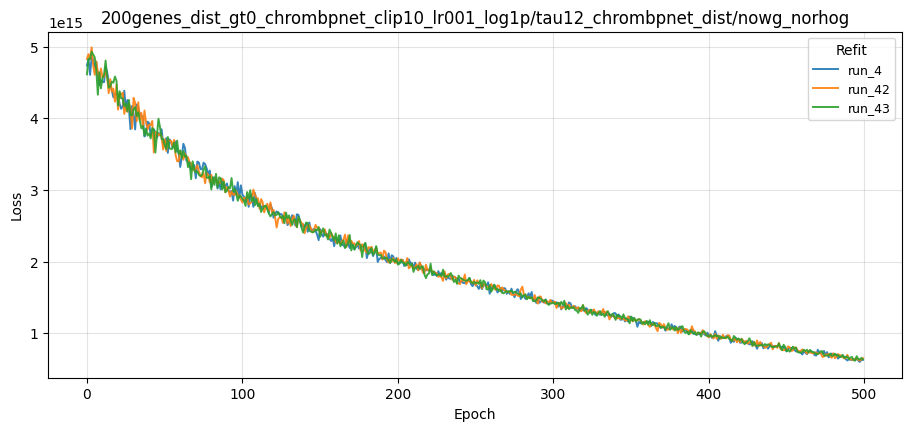

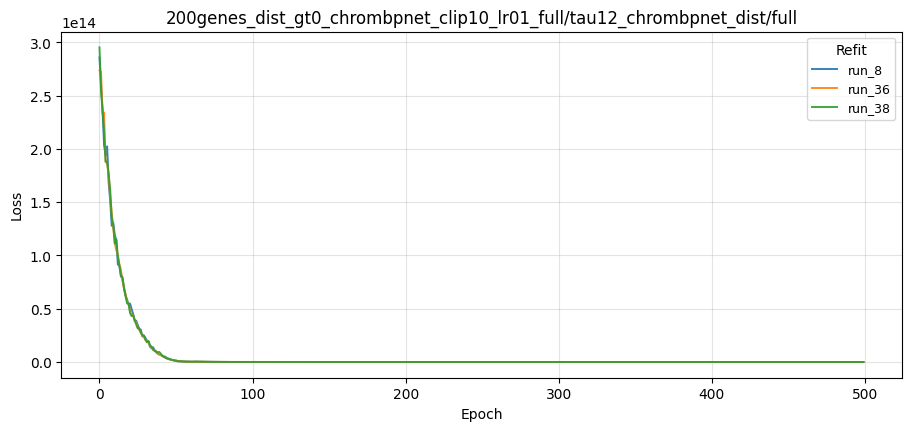

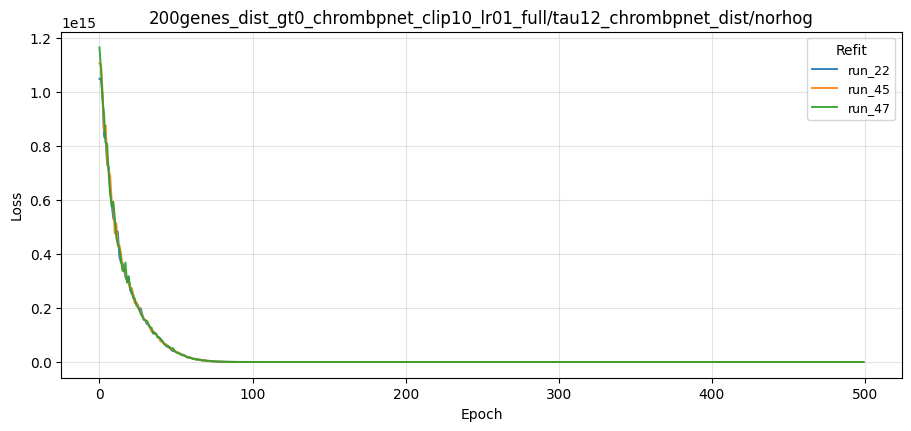

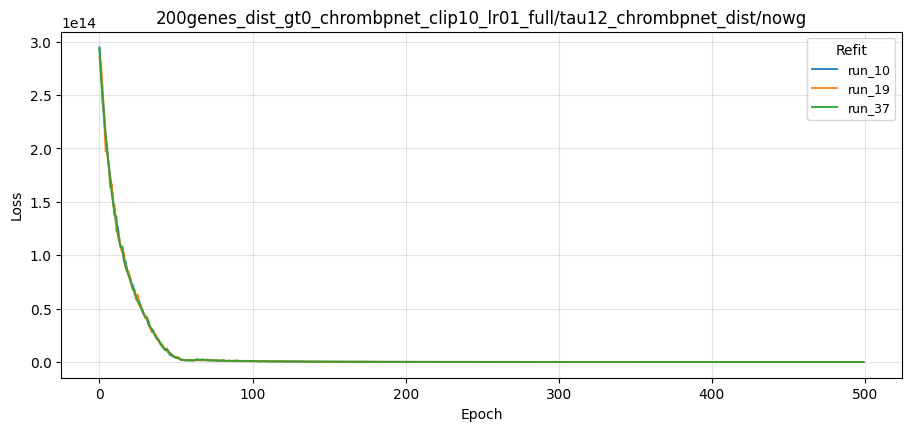

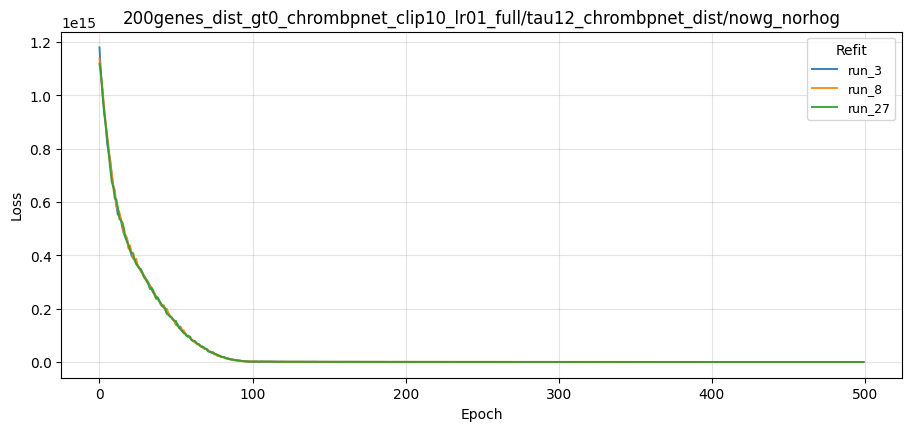

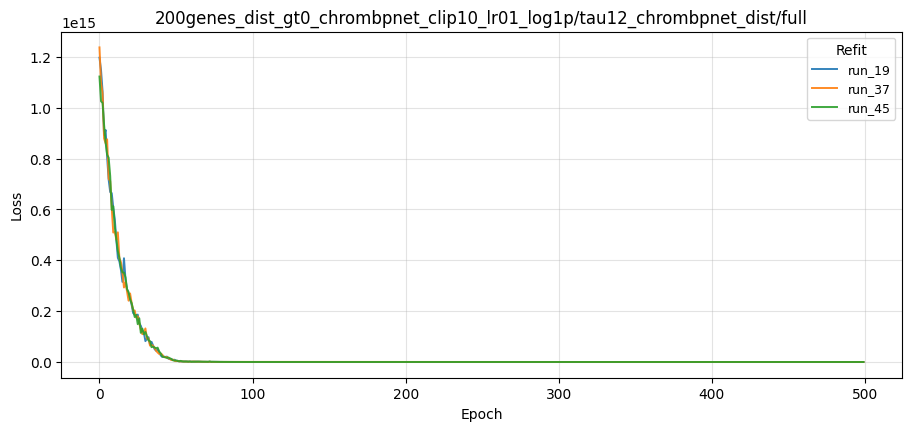

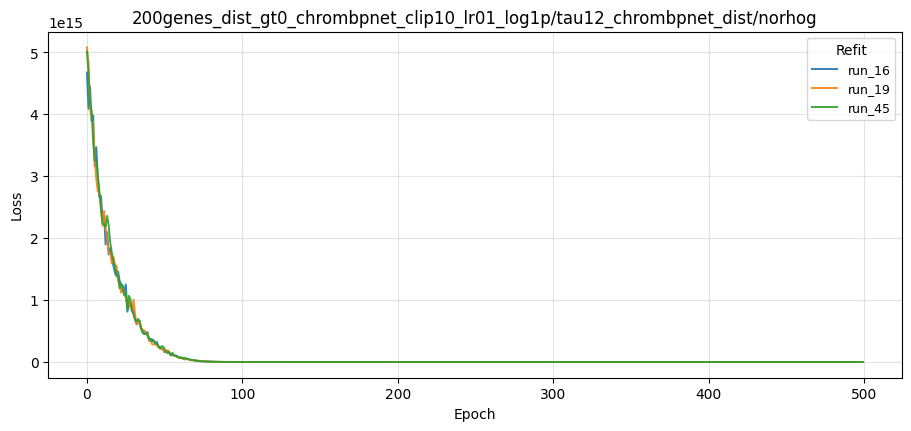

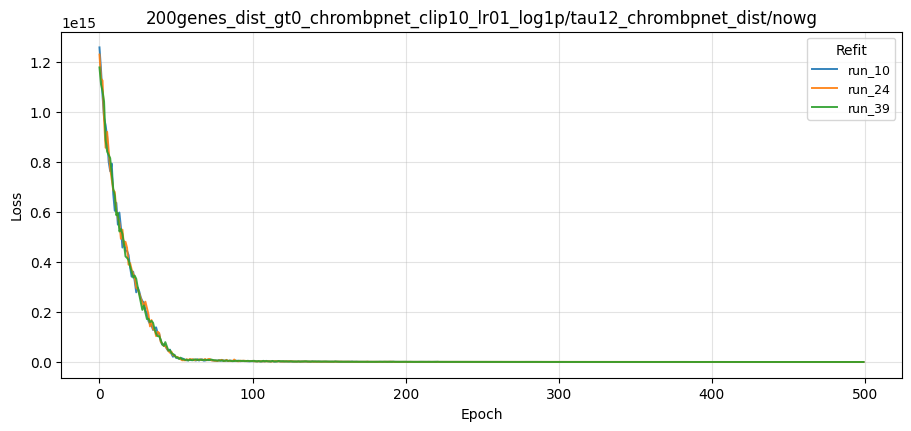

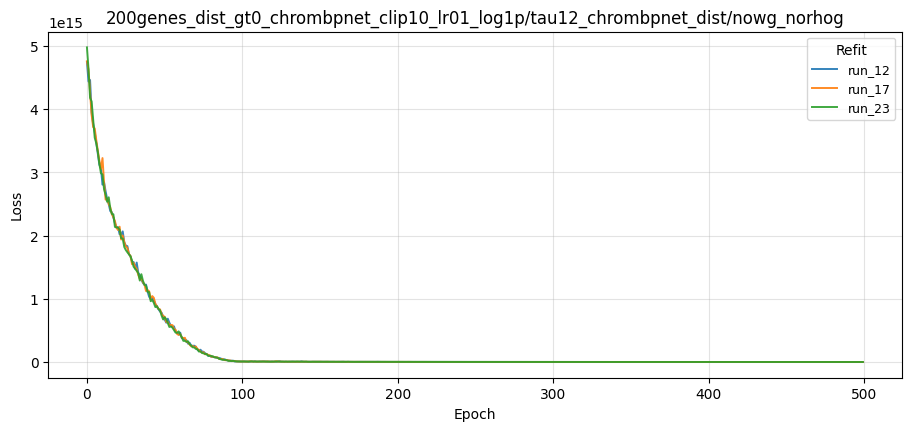

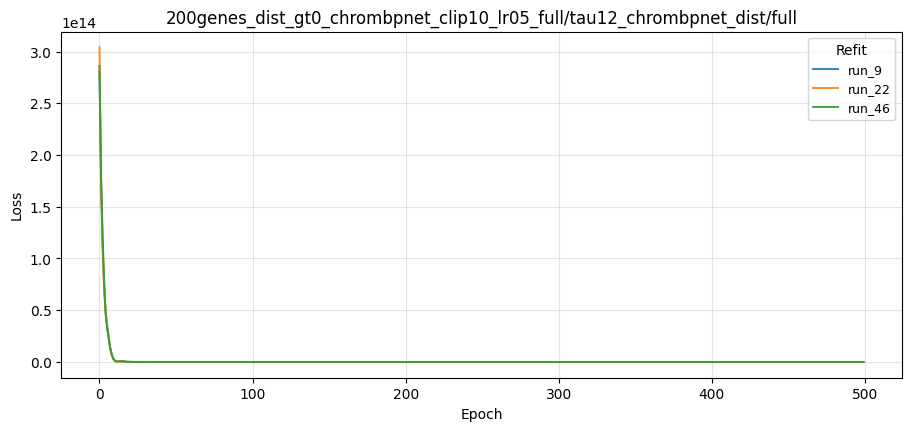

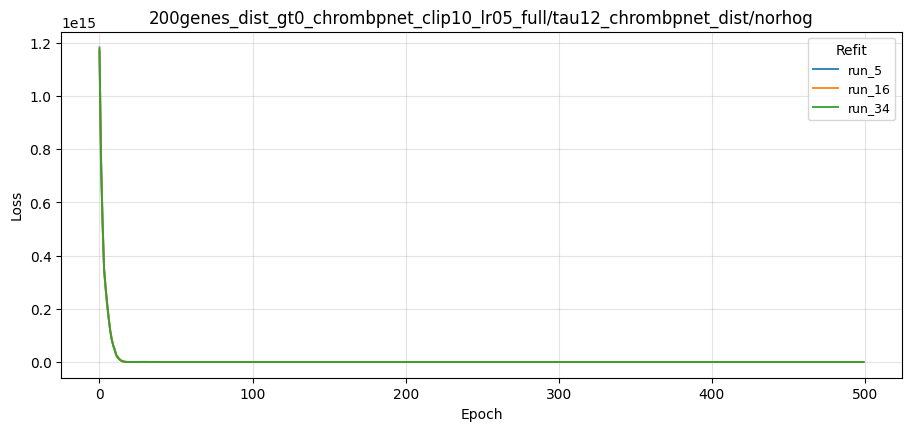

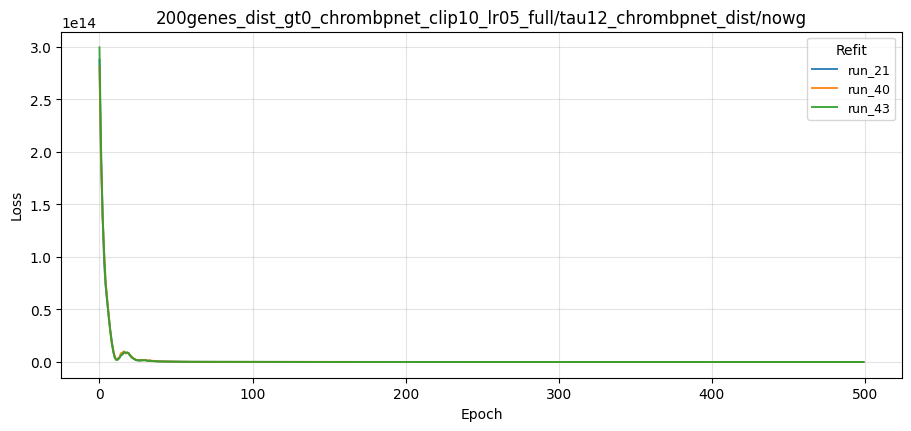

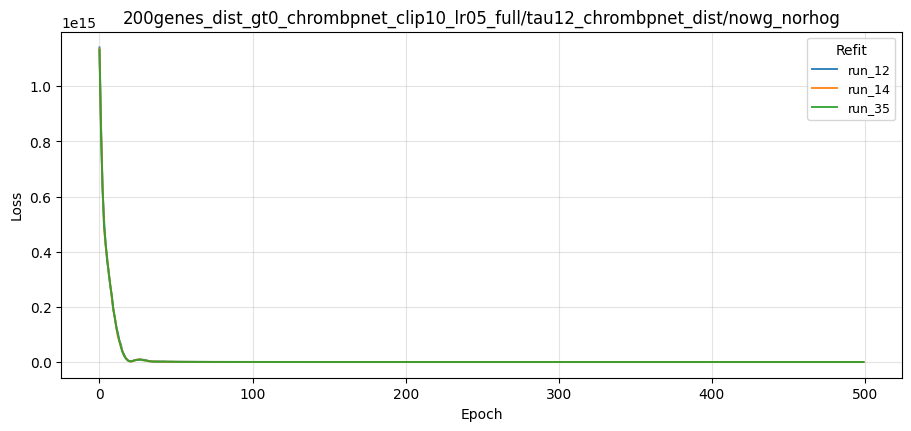

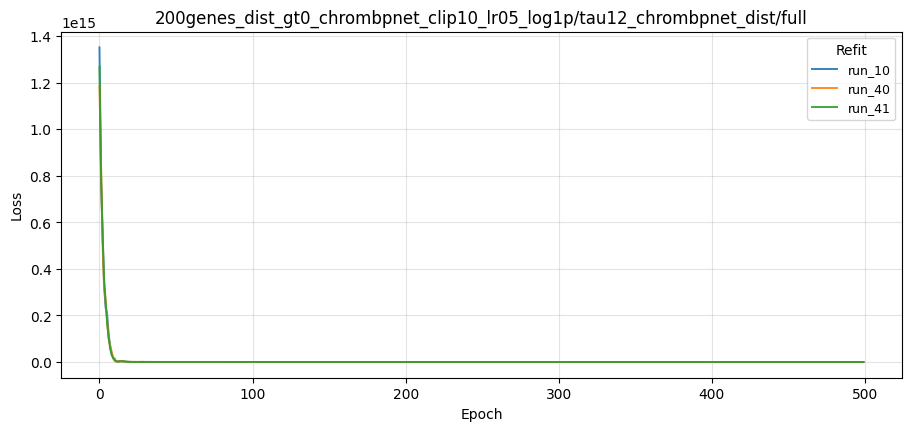

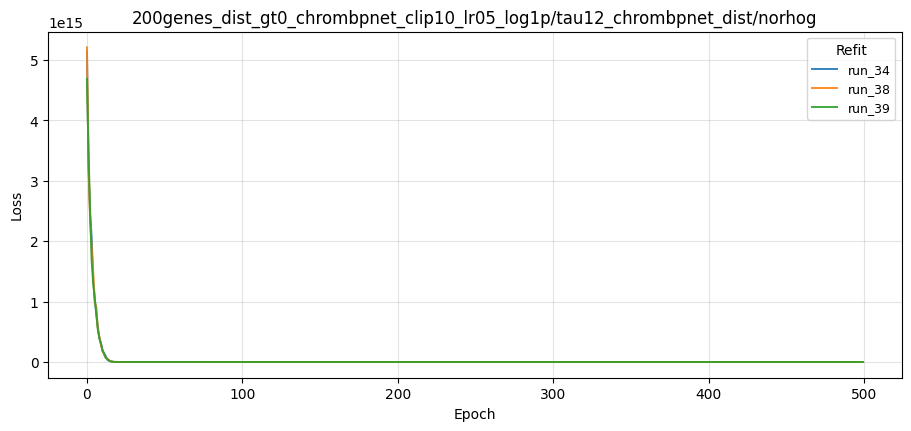

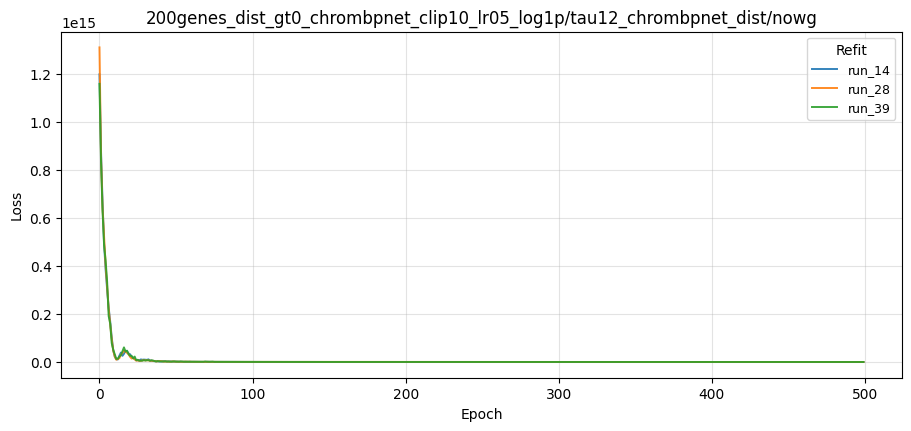

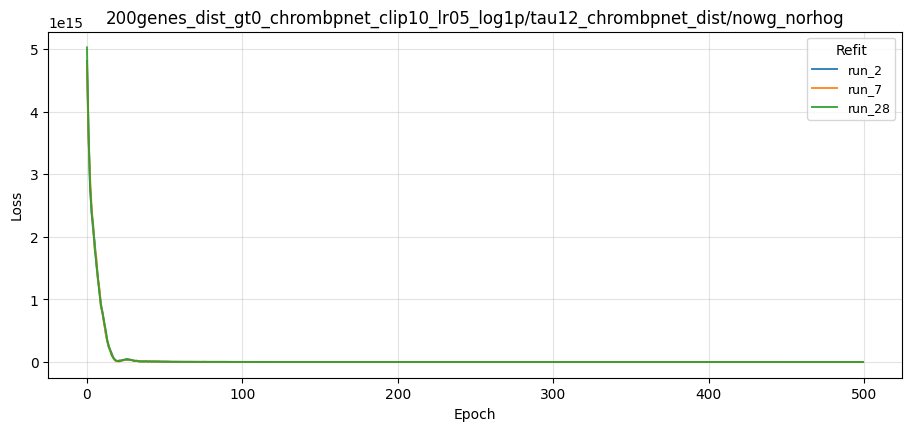

In [10]:
# --- adjust ---
N_RUNS_TO_PLOT = 3
RNG_SEED = 42
YSCALE = "linear"  # or "log" if curves span orders of magnitude

plot_loss_curves(
    n_runs_per_experiment=N_RUNS_TO_PLOT,
    rng_seed=RNG_SEED,
    yscale=YSCALE,
)